In [1]:
!pip install wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 5.5 MB/s eta 0:00:00


In [2]:
import os
import glob
import numpy as np
import pandas as pd
import wfdb
import joblib
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image as PILImage
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization,
                                     GlobalAveragePooling2D, LSTM, GRU,
                                     SimpleRNN, Bidirectional, Input,
                                     Concatenate)
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

# ── Paths ─────────────────────────────────────────────────
DATA_DIR   = '/kaggle/input/datasets/annapoornaak/phase2-dataset/ctu-chb-intrapartum-cardiotocography-database-1.0.0'
LABELS_CSV = '/kaggle/input/datasets/annn51/generated-labels-for-ctg/patient_labels.csv'
OUTPUT_DIR = '/kaggle/working/processed_data'
MODEL_DIR  = '/kaggle/working/models'
PLOTS_DIR  = '/kaggle/working/plots'

for d in [OUTPUT_DIR, MODEL_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

2026-03-03 18:56:00.432763: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772564160.620656      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772564160.671497      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772564161.107768      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772564161.107811      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772564161.107814      24 computation_placer.cc:177] computation placer alr

# SECTION 1 — PREPROCESSING


* **Downsampling (4 Hz → 1 Hz)**
  * **Theory**: CTG signals are recorded at **4 samples per second (4 Hz)**. For analysis, signals are typically converted to **1 sample per second (1 Hz)**. This reduces noise, decreases data size, and standardizes the temporal resolution used for fetal heart rate analysis.
  * **Code**: The signal is divided into groups of **4 samples (1 second)** using reshaping (`reshape(-1, 4)`). The mean of each group is computed using `np.nanmean(..., axis=1)`, which averages the values while ignoring missing values (`NaN`). This produces a **1 Hz signal** where each value represents the average heart rate during one second.

* **Interpolation of Missing Values**
  * **Theory**: CTG recordings often contain **missing values (`NaN`)** due to fetal movement, sensor displacement, or temporary signal loss. To maintain a continuous signal for analysis, **linear interpolation** is used to estimate the missing values by assuming the signal changes smoothly between neighboring valid points.
  * **Code**: The signals are placed into a Pandas DataFrame and interpolated using `interpolate(method='linear')`. A gap limit of **10 minutes** is enforced using `limit = max_gap_mins × 60`, meaning only gaps **≤ 600 samples** are filled. The parameter `limit_direction='both'` allows interpolation **forward and backward**, ensuring missing values at the beginning or end of gaps can also be filled.

* **Extracting the Latest Valid CTG Segment**
  * **Theory**: CTG recordings may contain missing regions due to signal loss. For analysis, we need a **continuous segment of the signal** that is long enough to represent fetal behavior. The algorithm identifies **continuous valid portions of the signal** where both FHR and UC are present. From these, the **latest valid block** of sufficient length is selected because the most recent fetal condition is clinically most relevant.

  * **Code**: A boolean mask is created using  
    `valid_mask = ~np.isnan(fhr) & ~np.isnan(uc)`  
    which marks positions where **both signals are valid**. The code then scans the mask to find **continuous sequences of valid samples**. Each sequence of indices is stored as a block.

* **Minimum Segment Length**
  * **Theory**: Very short signal segments are unreliable for fetal assessment. Therefore, only blocks with a minimum duration of **10 minutes** are considered valid.
  * **Code**: The minimum length is converted to seconds:
  
    `min_len = min_len_mins × 60`
  
    During scanning, only blocks where `len(curr) ≥ min_len` are stored.

* **Selecting the Latest Valid Block**
  * **Theory**: Among all valid segments, the **latest one is selected** because fetal condition closer to delivery is more clinically meaningful.
  * **Code**: After collecting all blocks, the last one is chosen:
  
    `block = blocks[-1]`

* **Extracting the Signal Segment**
  * **Theory**: Once the block of valid indices is found, the corresponding portion of the FHR and UC signals is extracted.
  * **Code**: The signals are sliced using the indices of the selected block:
  
    `fhr_seg = fhr[block]`  
    `uc_seg = uc[block]`

* **Ensuring Fixed Segment Length (60 Minutes)**
  * **Theory**: Machine learning models require **signals of equal length**. Therefore, the extracted segment must be standardized to **60 minutes**.
  * **Code**: The target length is computed as
  
    `target_len = target_len_mins × 60`

* **If Segment is Too Long**
  * **Theory**: If the segment is longer than 60 minutes, only the **most recent 60 minutes** are kept.
  * **Code**:
  
    `fhr_seg = fhr_seg[-target_len:]`  
    `uc_seg  = uc_seg[-target_len:]`

* **If Segment is Too Short**
  * **Theory**: If the segment is shorter than 60 minutes, the beginning is **padded with zeros** so the signal reaches the required length.
  * **Code**:
  
    `pad = target_len - len(fhr_seg)`  
    `np.pad(fhr_seg, (pad,0), constant_values=0)`

* **Final Output**
  * **Theory**: The function returns **clean, fixed-length CTG segments** suitable for feature extraction or machine learning models.
  * **Code**:
  
    `return fhr_seg, uc_seg`

  * **Output Shape**:
  
    Each signal becomes a **3600-length array (60 minutes × 60 seconds)**.

In [ ]:
import wfdb

hea_files    = glob.glob(os.path.join(DATA_DIR, '*.hea'))
record_names = sorted([os.path.basename(f).replace('.hea', '') for f in hea_files])
print(f"Found {len(record_names)} records")

# calculates how many complete 1-second windows we can get based on the original sampling frequency, reshapes the signals to group samples into these windows, and then computes the mean for each window to create downsampled signals at 1 Hz. 
# Resample the FHR and UC signals to 1 Hz by averaging every 'original_fs' samples. This function takes the original FHR and UC signals, 
# This process helps to reduce the data size while still capturing important trends in the signals for analysis.
def resample_1hz(fhr, uc, original_fs=4):
    n_samples    = len(fhr) // original_fs # Number of 1Hz samples we can get and avoid partial windows
    fhr_reshaped = fhr[:n_samples*original_fs].reshape(-1, original_fs) # This groups every 4 samples into one row.

    #uc = [5,6,7,8, 10,11,9,8]
      #uc_reshaped =
          #[
          # [5,6,7,8]
         # [10,11,9,8]
         # ]  

    uc_reshaped  = uc[:n_samples*original_fs].reshape(-1,  original_fs) 
    with warnings.catch_warnings(): 
        warnings.simplefilter("ignore", category=RuntimeWarning) 
        fhr_1hz = np.nanmean(fhr_reshaped, axis=1) # Compute the mean for each 1-second window, ignoring NaN values. This gives us the downsampled FHR signal at 1 Hz.
        uc_1hz  = np.nanmean(uc_reshaped,  axis=1) 
    return fhr_1hz, uc_1hz

 # why 10 minutes? Because we want to fill in short periods of missing data without introducing too much uncertainty. Longer gaps may indicate a loss of signal or other issues that could lead to inaccurate interpolation.
  # Interpolate FHR with a max gap of 10 minutes (600 seconds)
def interpolate_missing(fhr, uc, max_gap_mins=10):
    df['uc']  = df['uc'].interpolate(method='linear',  limit=lim, limit_direction='both')
    return df['fhr'].values, df['uc'].values # Return as numpy arrays


def extract_latest_segment(fhr, uc, min_len_mins=10, target_len_mins=60):
    min_len    = min_len_mins    * 60
    target_len = target_len_mins * 60
    valid_mask = ~np.isnan(fhr) & ~np.isnan(uc) # Valid points where both FHR and UC are present
    blocks, curr = [], [] # Identify contiguous valid segments
    for i, v in enumerate(valid_mask):# Iterate through the valid mask t            o find contiguous segments  
        if v:
            curr.append(i) # If the current point is valid, add its index to the current segment
        else:
            if len(curr) >= min_len: blocks.append(curr) # If the current segment is long enough, save it
            curr = [] # Reset current segment for the next one

    if len(curr) >= min_len: blocks.append(curr) 

    if not blocks: return None, None# If no valid segments are found, return None

    block   = blocks[-1] # Take the latest valid segment
    fhr_seg = fhr[block] # Extract the FHR segment corresponding to the latest valid block
    uc_seg  = uc[block]

    if len(fhr_seg) > target_len: # If the segment is longer than the target length, take only the last part
        fhr_seg = fhr_seg[-target_len:] # Keep only the last 'target_len' samples of the FHR segment
        uc_seg  = uc_seg[-target_len:]

    elif len(fhr_seg) < target_len: # If the segment is shorter than the target length, pad it with zeros at the beginning
        pad     = target_len - len(fhr_seg)
        fhr_seg = np.pad(fhr_seg, (pad, 0), constant_values=0) # Pad the FHR segment with zeros at the beginning to reach the target length
        uc_seg  = np.pad(uc_seg,  (pad, 0), constant_values=0)

    return fhr_seg, uc_seg


# ── Process all records ───────────────────────────────────
processed_records = []
all_fhr_segs, all_uc_segs = [], []
excluded = 0

print("=== Processing signals ===")
for count, rec_name in enumerate(record_names): 
    try:
        record    = wfdb.rdrecord(os.path.join(DATA_DIR, rec_name)) # Read the record using wfdb, which will give us access to the signal data and metadata for the current record. The record object contains the raw signal data (FHR and UC) as well as information about the sampling frequency, signal names, and other metadata that may be useful for processing and analysis.
        fhr       = record.p_signal[:, 0]
        uc        = record.p_signal[:, 1]
        fhr_clean = np.where(fhr == 0, np.nan, fhr) # Replace 0s in FHR with NaN for better handling of missing data

        fhr_1hz, uc_1hz       = resample_1hz(fhr_clean, uc)# Downsample the FHR and UC signals to 1 Hz by averaging every 4 samples, which reduces the data size and focuses on the overall trends in the signals while still capturing important information for analysis.
        fhr_interp, uc_interp = interpolate_missing(fhr_1hz, uc_1hz) # Interpolate missing values in the downsampled signals with a maximum gap of 10 minutes, which helps to fill in short periods of missing data and allows for more complete analysis of the signals while avoiding excessive interpolation that could introduce inaccuracies.
        fhr_seg, uc_seg       = extract_latest_segment(fhr_interp, uc_interp) # Extract the latest valid segment of the interpolated signals that is at least 10 minutes long and take only the last hour of data, which ensures that we are analyzing a consistent and relevant portion of the signals for each record while also handling cases where there may be multiple valid segments.

        if fhr_seg is None: # If no valid segment is found, skip this record and count it as excluded
            excluded += 1
            continue

        processed_records.append(rec_name) # Keep track of successfully processed records
        all_fhr_segs.append(fhr_seg) # Append the extracted FHR segment to the list of all FHR segments
        all_uc_segs.append(uc_seg)

        if (count+1) % 50 == 0:
            print(f"  Processed {count+1}/{len(record_names)}")
    except Exception as e:
        print(f"  Failed {rec_name}: {e}")
        excluded += 1

FHR_data = np.array(all_fhr_segs)
UC_data  = np.array(all_uc_segs)
print(f"\nProcessed: {len(processed_records)} | Excluded: {excluded}")
print(f"FHR shape: {FHR_data.shape}")

# ── EDA plots ────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Sample signals
for i, ax in enumerate(axes[0]):
    ax.plot(FHR_data[i], color='blue', linewidth=0.5)
    ax.set_title(f'FHR — Patient {processed_records[i]}')
    ax.set_ylabel('BPM')
    ax.grid(True, alpha=0.3)

for i, ax in enumerate(axes[1]):
    ax.plot(UC_data[i], color='red', linewidth=0.5)
    ax.set_title(f'UC — Patient {processed_records[i]}')
    ax.set_ylabel('Intensity')
    ax.grid(True, alpha=0.3)

plt.suptitle('Sample CTG Signals After Preprocessing', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'sample_signals.png'))
plt.show()

# FHR distribution
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(FHR_data[FHR_data > 0].flatten(), bins=50, color='blue', alpha=0.7)
plt.title('FHR Value Distribution')
plt.xlabel('BPM')
plt.subplot(1, 2, 2)
plt.hist(UC_data.flatten(), bins=50, color='red', alpha=0.7)
plt.title('UC Value Distribution')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'signal_distributions.png'))
plt.show()

# ── Load labels ───────────────────────────────────────────
df_labels  = pd.read_csv(LABELS_CSV)
df_labels['Patient_ID'] = df_labels['Patient_ID'].astype(str)
label_dict = dict(zip(df_labels['Patient_ID'], df_labels['label']))

labels = np.array([label_dict.get(str(r), -1) for r in processed_records])
valid  = labels != -1

FHR_data = FHR_data[valid]
UC_data  = UC_data[valid]
labels   = labels[valid]
processed_records = [r for r, v in zip(processed_records, valid) if v]

print(f"\nMatched labels: {len(labels)}")
print(f"Class distribution: {np.bincount(labels)}")

# Label distribution plot
plt.figure(figsize=(6, 4))
label_names = ['Normal', 'Suspect', 'Pathologic']
counts      = np.bincount(labels)
plt.bar(label_names, counts, color=['green', 'orange', 'red'])
plt.title('Class Distribution')
plt.ylabel('Count')
for i, c in enumerate(counts):
    plt.text(i, c+1, str(c), ha='center', fontweight='bold')
plt.savefig(os.path.join(PLOTS_DIR, 'class_distribution.png'))
plt.show()


Found 552 records
=== Processing signals ===
  Processed 50/552
  Processed 100/552
  Processed 150/552
  Processed 200/552
  Processed 250/552
  Processed 300/552
  Processed 350/552
  Processed 400/552
  Processed 450/552
  Processed 500/552
  Processed 550/552

Processed: 552 | Excluded: 0
FHR shape: (552, 3600)

Matched labels: 552
Class distribution: [464  30  58]


# SECTION 2 — TRAIN/TEST/VAL SPLIT + NORMALIZATION


* **Normalization of Test Data**
  * **Theory**: In machine learning, normalization ensures that input features have a consistent scale. Signals such as **FHR (Fetal Heart Rate)** and **UC (Uterine Contractions)** may have different ranges across patients, which can make model training unstable. Normalization transforms the data so that values are centered around **mean ≈ 0** with **standard deviation ≈ 1**.
  * **Key Principle**: The **mean and standard deviation must be computed only from the training data**. Test and validation sets should never influence these statistics, otherwise it introduces **data leakage**, which makes model evaluation unreliable.
  * **Code**: The training set statistics are computed using:
    ```python
    FHR_mean = np.nanmean(FHR_data[train_idx])
    FHR_std  = np.nanstd(FHR_data[train_idx])
    ```
    All datasets are then normalized using the same parameters:
    ```python
    (data - mean) / (std + 1e-8)
    ```
  * **Reason Test Data is Normalized**: Test data is normalized using the **training mean and standard deviation** so that the model receives inputs in the **same scale it was trained on**, while ensuring the test set remains **completely unseen during training**.

In [ ]:
indices = np.arange(len(labels))
# 70% train, 15% test, 15% val with stratification
train_idx, test_val_idx = train_test_split(indices, test_size=0.30,
                                            random_state=42, stratify=labels)
test_idx, val_idx       = train_test_split(test_val_idx, test_size=0.50,
                                            random_state=42,
                                            stratify=labels[test_val_idx])

print(f"Train: {len(train_idx)} | Test: {len(test_idx)} | Val: {len(val_idx)}")

# Normalize using train stats only
FHR_mean = np.nanmean(FHR_data[train_idx]) # Compute mean of FHR using only training data to avoid data leakage
FHR_std  = np.nanstd(FHR_data[train_idx]) # Compute std of FHR using only training data
UC_mean  = np.nanmean(UC_data[train_idx])
UC_std   = np.nanstd(UC_data[train_idx])

def normalize(data, mean, std):
    return (data - mean) / (std + 1e-8) # Normalize data using the mean and std computed from the training set, adding a small epsilon to avoid division by zero

FHR_train = normalize(FHR_data[train_idx], FHR_mean, FHR_std)
FHR_test  = normalize(FHR_data[test_idx],  FHR_mean, FHR_std)  # why use train mean/std for test and val? To prevent data leakage and ensure that the model is evaluated on data that has been normalized in the same way as the training data, which is crucial for consistent performance assessment.
FHR_val   = normalize(FHR_data[val_idx],   FHR_mean, FHR_std)

UC_train  = normalize(UC_data[train_idx], UC_mean, UC_std)
UC_test   = normalize(UC_data[test_idx],  UC_mean, UC_std)
UC_val    = normalize(UC_data[val_idx],   UC_mean, UC_std)

y_train   = labels[train_idx]
y_test    = labels[test_idx]
y_val     = labels[val_idx]

# Save splits for Notebook 2
np.save(os.path.join(OUTPUT_DIR, 'FHR_train.npy'), FHR_train) # dim: (num_train_samples, 3600) — saved normalized FHR training data
np.save(os.path.join(OUTPUT_DIR, 'FHR_test.npy'),  FHR_test)# dim: (num_test_samples, 3600) — saved normalized FHR test data
np.save(os.path.join(OUTPUT_DIR, 'FHR_val.npy'),   FHR_val) # dim: (num_val_samples, 3600) — saved normalized FHR validation data
np.save(os.path.join(OUTPUT_DIR, 'UC_train.npy'),  UC_train) # dim: (num_train_samples, 3600) — saved normalized UC training data
np.save(os.path.join(OUTPUT_DIR, 'UC_test.npy'),   UC_test)
np.save(os.path.join(OUTPUT_DIR, 'UC_val.npy'),    UC_val)# dim: (num_val_samples, 3600) — saved normalized UC validation data
np.save(os.path.join(OUTPUT_DIR, 'y_train.npy'),   y_train)
np.save(os.path.join(OUTPUT_DIR, 'y_test.npy'),    y_test)
np.save(os.path.join(OUTPUT_DIR, 'y_val.npy'),     y_val) # dim: (num_val_samples,) — saved labels for validation set
print("✓ Splits saved")


Train: 386 | Test: 83 | Val: 83
✓ Splits saved


# SECTION 3 — WINDOWING


This code converts each 60-minute CTG signal (3600 samples) into smaller time windows so sequence models (RNN/LSTM/GRU) can learn temporal patterns.

* **Sliding Window Generation**

  * **Theory**: Each CTG recording represents **60 minutes** of fetal monitoring sampled at **1 Hz**, meaning there is **1 sample per second**. Therefore, each patient signal contains:

  $$
  60 \text{ minutes} \times 60 \text{ seconds} = 3600 \text{ samples}
  $$

  Instead of using the entire signal at once, the signal is divided into **smaller overlapping segments (windows)**. This helps the model learn **local temporal patterns** in the fetal heart rate (FHR) and uterine contraction (UC) signals and also increases the number of training samples.

* **Window Parameters**

  * **Window Size (`WINDOW`)**: 600 samples → **10 minutes of signal**
  * **Stride (`STEP`)**: 300 samples → **5-minute shift between windows**

  Since the stride is smaller than the window size, the windows **overlap**, allowing the model to capture patterns that may occur near window boundaries.

* **Number of Windows per Patient**

  For a signal of length **3600 samples**, the number of windows generated using a sliding window is:

  $$
  \text{Number of windows} =
  \frac{(\text{signal length} - \text{window size})}{\text{step}} + 1
  $$

  Substituting the values:

  $$
  \frac{(3600 - 600)}{300} + 1
  $$

  $$
  = \frac{3000}{300} + 1
  $$

  $$
  = 10 + 1 = 11
  $$

  Therefore, **each patient produces 11 overlapping windows**.

* **Example Window Positions**
Window 1 : 0 – 600<br>
Window 2 : 300 – 900<br>
Window 3 : 600 – 1200<br>
Window 4 : 900 – 1500<br>
Window 5 : 1200 – 1800<br>
Window 6 : 1500 – 2100<br>
Window 7 : 1800 – 2400<br>
Window 8 : 2100 – 2700<br>
Window 9 : 2400 – 3000<br>
Window 10: 2700 – 3300<br>
Window 11: 3000 – 3600


* **Total Windows in the Training Set**

If each patient produces approximately **11 windows**, then the total number of training windows depends on the number of training patients. After applying the sliding window process to all training signals, the dataset becomes:<br>
X_tr_seq → (4246, 600, 2)

Where:

* **4246** → total number of windows (training samples)
* **600** → time steps per window (**10 minutes**)
* **2** → features per time step (**FHR and UC signals**)

Each training sample therefore represents a **10-minute sequence of CTG data containing both FHR and UC signals**, which is suitable for training sequence models such as **LSTM, CNN-1D, or Transformers**.


In [ ]:
WINDOW = 600   # 10 minutes at 1Hz
STEP   = 300   # 5 minute stride

# three checks per window:
# 1) If more than 30% of the FHR window is NaN, skip this window to ensure data quality.
# 2) Replace any remaining NaNs in FHR and UC with 0.0 to ensure the model can process the data without errors.
# 3) Stack FHR and UC windows together to create a 2-channel input for the model, which allows the model to learn from both signals simultaneously and capture their interactions for better analysis and prediction

def create_windows(FHR, UC, y): 
    X_wins, y_wins = [], [] # Create windows of FHR and UC data with corresponding labels
    for i in range(len(FHR)):
        for start in range(0, len(FHR[i]) - WINDOW + 1, STEP): # Slide a window of size 600 with a stride of 300 across the FHR and UC signals
            fhr_w = FHR[i][start:start+WINDOW]# Extract the FHR window for the current position of the sliding window, which will be used as input to the model. This window captures a 10-minute segment of the FHR signal at 1 Hz, providing temporal context for analysis.
            uc_w  = UC[i][start:start+WINDOW]
            if np.sum(np.isnan(fhr_w)) > WINDOW * 0.3: # If more than 30% of the FHR window is NaN, skip this window to ensure data quality
                continue
            fhr_w = np.nan_to_num(fhr_w, nan=0.0) # Replace any remaining NaNs in FHR with 0.0 to ensure the model can process the data without errors
            uc_w  = np.nan_to_num(uc_w,  nan=0.0)
            X_wins.append(np.stack([fhr_w, uc_w], axis=-1)) # Stack FHR and UC windows together to create a 2-channel input for the model
            y_wins.append(y[i]) # Append the corresponding label for this window, which allows the model to learn from both signals simultaneously and capture their interactions for better analysis and prediction
    return np.array(X_wins, dtype=np.float32), np.array(y_wins)

print("Creating windows...")
X_tr_seq, y_tr_seq = create_windows(FHR_train, UC_train, y_train) # Create windows for training data
X_te_seq, y_te_seq = create_windows(FHR_test,  UC_test,  y_test)
X_va_seq, y_va_seq = create_windows(FHR_val,   UC_val,   y_val)

print(f"Train: {X_tr_seq.shape} | Test: {X_te_seq.shape} | Val: {X_va_seq.shape}")

# Save sequences for Notebook 2
np.save(os.path.join(OUTPUT_DIR, 'X_tr_seq.npy'), X_tr_seq)
np.save(os.path.join(OUTPUT_DIR, 'X_te_seq.npy'), X_te_seq)
np.save(os.path.join(OUTPUT_DIR, 'X_va_seq.npy'), X_va_seq)
np.save(os.path.join(OUTPUT_DIR, 'y_tr_seq.npy'), y_tr_seq)
np.save(os.path.join(OUTPUT_DIR, 'y_te_seq.npy'), y_te_seq)
np.save(os.path.join(OUTPUT_DIR, 'y_va_seq.npy'), y_va_seq)
print("✓ Sequences saved")

Creating windows...
Train: (4246, 600, 2) | Test: (913, 600, 2) | Val: (913, 600, 2)
✓ Sequences saved


# SECTION 4 — CONVERT WINDOWS TO IMAGES


* **Converting CTG Windows to Images**

  * **Goal**: Transform each **10-minute CTG window** (containing FHR and UC signals) into a **224 × 224 RGB image** so that it can be used as input for **CNN models** such as MobileNetV2, ResNet, or EfficientNet.

---

* **Function 1 — `window_to_image(fhr_w, uc_w)`**

  * **Input**:
    * `fhr_w` → Fetal Heart Rate window (length = 600 samples)
    * `uc_w` → Uterine Contraction window (length = 600 samples)

  * **Step 1: Create a plotting canvas**

    ```python
    fig, (ax1, ax2) = plt.subplots(2,1, figsize=(2.24,2.24), dpi=100)
    ```

    The image resolution is determined by:

    $$
    \text{pixels} = \text{figure size} \times \text{dpi}
    $$

    $$
    2.24 \times 100 = 224
    $$

    Therefore the figure becomes:

    ```
    224 × 224 pixels
    ```

    The layout contains **two subplots**:

    ```
    ┌───────────────┐
    │  FHR signal   │
    ├───────────────┤
    │  UC signal    │
    └───────────────┘
    ```

  * **Step 2: Plot the signals**

    ```
    ax1.plot(fhr_w) → FHR waveform (blue)
    ax2.plot(uc_w)  → UC waveform (red)
    ```

    Axes are removed using:

    ```
    ax.axis('off')
    ```

    This ensures the CNN learns **signal patterns rather than axis labels**.

  * **Step 3: Render the figure**

    ```
    fig.canvas.draw()
    ```

    This converts the plotted figure into **pixel data stored in memory**.

  * **Step 4: Extract pixel values**

    ```
    buf = np.asarray(fig.canvas.buffer_rgba())
    ```

    The canvas returns an array of shape:

    ```
    (224, 224, 4)
    ```

    where the channels represent:

    ```
    R, G, B, Alpha
    ```

  * **Step 5: Convert RGBA → RGB**

    ```
    img = buf[:, :, :3]
    ```

    Final shape becomes:

    ```
    (224, 224, 3)
    ```

  * **Step 6: Resize and normalize**

    The image is converted to a PIL image and resized:

    ```
    img = PILImage.fromarray(img).resize((224,224))
    ```

    Pixel values are normalized:

    $$
    I_{norm} = \frac{I}{255}
    $$

    This scales values from:

    ```
    0–255 → 0–1
    ```

  * **Output**:

    ```
    (224, 224, 3) image representing the CTG window
    ```

---

* **Function 2 — `seqs_to_images(X_seq, name)`**

  * **Input**:

    ```
    X_seq → CTG windows
    ```

    Shape:

    ```
    (num_windows, 600, 2)
    ```

    where:

    ```
    600 → time steps
    2   → signals (FHR, UC)
    ```

  * **Step 1: Iterate over each window**

    ```python
    for i, win in enumerate(X_seq)
    ```

  * **Step 2: Separate signals**

    ```
    win[:,0] → FHR
    win[:,1] → UC
    ```

  * **Step 3: Convert the window to an image**

    ```
    window_to_image(win[:,0], win[:,1])
    ```

    The resulting image is appended to the list.

  * **Step 4: Progress tracking**

    Every 100 windows:

    ```
    print([name] progress)
    ```

    Example:

    ```
    [train] 100/4246
    ```

  * **Step 5: Convert list to NumPy array**

    ```
    np.array(imgs, dtype=float32)
    ```

---

* **Final Data Representation**

  After processing all windows, the dataset becomes:<br>
  X_tr_img → (4246, 224, 224, 3)<br>


where:

| Dimension | Meaning |
|---|---|
4246 | number of CTG windows |
224 | image height |
224 | image width |
3 | RGB channels |

Each image visually encodes a **10-minute CTG signal segment**, allowing convolutional neural networks to learn **temporal signal patterns through spatial image features**.

In [ ]:
IMG_SIZE = 224


def window_to_image(fhr_w, uc_w):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(2.24, 2.24), dpi=100) # Create a figure with 2 subplots (one for FHR and one for UC) with a size of 224x224 pixels
    fig.patch.set_facecolor('white') # Set the background color of the figure to white
    ax1.plot(fhr_w, color='blue', linewidth=0.8) # Plot the FHR window in blue on the first subplot
    ax1.axis('off') # Remove axes for a cleaner look
    ax2.plot(uc_w,  color='red',  linewidth=0.8) # Plot the UC window in red on the second subplot
    ax2.axis('off')
    plt.tight_layout(pad=0) # Adjust layout to remove any padding around the plots
    fig.canvas.draw() # Render the figure to access the pixel data

    # Fix for newer matplotlib versions
    buf = np.asarray(fig.canvas.buffer_rgba())  # RGBA  # # grab raw pixels
    img = buf[:, :, :3]                          # drop alpha → RGB
    plt.close(fig) # Close the figure to free memory

    img = PILImage.fromarray(img).resize((IMG_SIZE, IMG_SIZE)) # Convert the RGB array to a PIL image and resize it to the target size of 224x224 pixels
    return np.array(img, dtype=np.float32) / 255.0 # Normalize pixel values to [0, 1]

def seqs_to_images(X_seq, name): # Convert each window in the sequence to an image using the window_to_image function
    imgs = []
    for i, win in enumerate(X_seq): # Iterate through each window in the sequence and convert it to an image
        imgs.append(window_to_image(win[:, 0], win[:, 1])) # Convert the FHR and UC channels of the window to an image and append it to the list of images
        if (i+1) % 100 == 0: # Print progress every 100 windows to keep track of the conversion process
            print(f"  [{name}] {i+1}/{len(X_seq)}")
    return np.array(imgs, dtype=np.float32)

print("\nConverting to images...")
X_tr_img = seqs_to_images(X_tr_seq, 'train')
X_te_img = seqs_to_images(X_te_seq, 'test')
X_va_img = seqs_to_images(X_va_seq, 'val')
print(f"Images — Train: {X_tr_img.shape} | Test: {X_te_img.shape}")

# Save images for Notebook 2
np.save(os.path.join(OUTPUT_DIR, 'X_tr_img.npy'), X_tr_img)
np.save(os.path.join(OUTPUT_DIR, 'X_te_img.npy'), X_te_img)
np.save(os.path.join(OUTPUT_DIR, 'X_va_img.npy'), X_va_img)
print("✓ Images saved")

# Sample image preview
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, ax in enumerate(axes):
    ax.imshow(X_tr_img[i*10])
    ax.set_title(f'Label: {["Normal","Suspect","Pathologic"][y_tr_seq[i*10]]}')
    ax.axis('off')
plt.suptitle('Sample CTG Window Images')
plt.savefig(os.path.join(PLOTS_DIR, 'sample_images.png'))
plt.show()



Converting to images...
  [train] 100/4246
  [train] 200/4246
  [train] 300/4246
  [train] 400/4246
  [train] 500/4246
  [train] 600/4246
  [train] 700/4246
  [train] 800/4246
  [train] 900/4246
  [train] 1000/4246
  [train] 1100/4246
  [train] 1200/4246
  [train] 1300/4246
  [train] 1400/4246
  [train] 1500/4246
  [train] 1600/4246
  [train] 1700/4246
  [train] 1800/4246
  [train] 1900/4246
  [train] 2000/4246
  [train] 2100/4246
  [train] 2200/4246
  [train] 2300/4246
  [train] 2400/4246
  [train] 2500/4246
  [train] 2600/4246
  [train] 2700/4246
  [train] 2800/4246
  [train] 2900/4246
  [train] 3000/4246
  [train] 3100/4246
  [train] 3200/4246
  [train] 3300/4246
  [train] 3400/4246
  [train] 3500/4246
  [train] 3600/4246
  [train] 3700/4246
  [train] 3800/4246
  [train] 3900/4246
  [train] 4000/4246
  [train] 4100/4246
  [train] 4200/4246
  [test] 100/913
  [test] 200/913
  [test] 300/913
  [test] 400/913
  [test] 500/913
  [test] 600/913
  [test] 700/913
  [test] 800/913
  [test]

# SECTION 5 — CLASS WEIGHTS & CALLBACKS


In [ ]:
cw_arr      = compute_class_weight('balanced', classes=np.unique(y_tr_seq), y=y_tr_seq) # how? The compute_class_weight function from sklearn calculates weights for each class based on their frequency in the training labels (y_tr_seq). The 'balanced' mode automatically adjusts the weights inversely proportional to the class frequencies
class_weights = dict(enumerate(cw_arr))
print(f"Class weights: {class_weights}")

y_tr_cat = to_categorical(y_tr_seq, 3) # 3 classes → one-hot encode the labels for training, testing, and validation sets to prepare them for multi-class classification with the model
y_te_cat = to_categorical(y_te_seq, 3)
y_va_cat = to_categorical(y_va_seq, 3)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=0)
]


Class weights: {0: np.float64(0.39711934156378603), 1: np.float64(6.126984126984127), 2: np.float64(3.138211382113821)}


# SECTION 6 — RESNET50 HYBRID MODEL


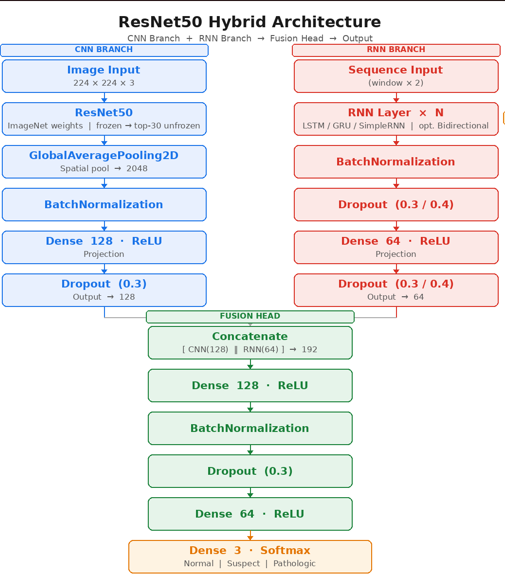

In [ ]:
def build_resnet_hybrid(rnn_arch, rnn_units, rnn_layers,
                        bidirectional=False, dropout=0.3):
    # CNN branch
    img_input = Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='img_input') # Define the input layer for the CNN branch, which expects images of size 224x224 with 3 color channels (RGB)
    base      = ResNet50(weights='imagenet', include_top=False,
                         input_tensor=img_input)
    base.trainable = False # Freeze the ResNet50 layers during the initial training phase to leverage pre-trained features without updating them, which helps in faster convergence and prevents overfitting on the small dataset

    cnn_x = GlobalAveragePooling2D()(base.output) # base.output is the feature map from ResNet50, which is then pooled to create a fixed-size feature vector for the CNN branch of the model
    cnn_x = BatchNormalization()(cnn_x)
    cnn_x = Dense(128, activation='relu')(cnn_x)
    cnn_x = Dropout(dropout)(cnn_x)

    # RNN branch
    seq_input = Input(shape=(WINDOW, 2), name='seq_input') # Define the input layer for the RNN branch, which expects sequences of shape (600, 2) corresponding to the FHR and UC channels of the CTG data
    layer_fn  = {'LSTM': LSTM, 'GRU': GRU, 'RNN': SimpleRNN}[rnn_arch] #rnn_arch is a string that specifies the type of RNN layer to use (LSTM, GRU, or SimpleRNN). The corresponding Keras layer class is selected from the dictionary and stored in layer_fn for later use when building the RNN layers of the model.

    x = seq_input # Start with the sequence input for the RNN branch, which will be processed through multiple RNN layers as defined by the experiment configurations
    for i in range(rnn_layers): #3 Loop through the number of RNN layers specified in the experiment configuration to build a multi-layer RNN architecture. Each layer will process the output of the previous layer, allowing the model to learn more complex temporal patterns in the CTG data.
        ret_seq = (i < rnn_layers - 1) # True if current layer is not the last one, meaning it should return the full sequence for the next layer to process, otherwise it should return only the last output for the final classification layer.
        layer   = layer_fn(rnn_units, return_sequences=ret_seq) #LSTM(128, return_sequences=True)
        x       = Bidirectional(layer)(x) if bidirectional else layer(x) # If bidirectional is True, wrap the RNN layer in a Bidirectional layer to allow the model to learn from both past and future context in the sequence data. Otherwise, use the RNN layer as is for unidirectional processing.
        x       = BatchNormalization()(x)
        x       = Dropout(dropout)(x)

    rnn_x = Dense(64, activation='relu')(x)
    rnn_x = Dropout(dropout)(rnn_x)

    # Merge
    merged = Concatenate()([cnn_x, rnn_x])  
    merged = Dense(128, activation='relu')(merged)
    merged = BatchNormalization()(merged)
    merged = Dropout(0.3)(merged)
    merged = Dense(64,  activation='relu')(merged)
    output = Dense(3, activation='softmax')(merged)

    model = Model(inputs=[img_input, seq_input], outputs=output) # Create the final model by specifying the inputs (image and sequence) and the output (class probabilities). The model architecture combines the features extracted from the CNN branch with the temporal features learned by the RNN branch, allowing it to make predictions based on both spatial and temporal information from the CTG data.
    model.compile(Adam(1e-3), 'categorical_crossentropy', metrics=['accuracy'])
    return model, base

# Experiment configs
resnet_configs = [
    # (rnn,    units, layers, bidir,  dropout)
    ('LSTM',   64,    1,      False,  0.3),
    ('LSTM',   128,   2,      False,  0.3),
    ('LSTM',   128,   3,      False,  0.4),
    ('LSTM',   256,   2,      False,  0.3),
    ('LSTM',   128,   2,      True,   0.3),  # BiLSTM
    ('LSTM',   256,   3,      True,   0.4),  # BiLSTM deep
    ('GRU',    64,    1,      False,  0.3),
    ('GRU',    128,   2,      False,  0.3),
    ('GRU',    128,   3,      False,  0.4),
    ('GRU',    256,   2,      False,  0.3),
    ('GRU',    128,   2,      True,   0.3),  # BiGRU
    ('GRU',    256,   3,      True,   0.4),  # BiGRU deep
    ('RNN',    64,    1,      False,  0.3),
    ('RNN',    128,   2,      False,  0.3),
    ('RNN',    128,   2,      True,   0.3),  # BiRNN
]

resnet_results  = {}
resnet_histories = {}

for rnn, units, layers, bidir, dropout in resnet_configs:
    name = f"ResNet50+{'Bi' if bidir else ''}{rnn}_{layers}L_{units}u"
    print(f"\n{'='*55}\n{name}")

    model, base = build_resnet_hybrid(rnn, units, layers, bidir, dropout)

    # Phase 1 — frozen ResNet
    print("  Phase 1: frozen ResNet...")
    h1 = model.fit( #  What data is being used for training and validation in this phase? The model is being trained on the training images (X_tr_img) and sequences (X_tr_seq) with their corresponding one-hot encoded labels (y_tr_cat). The validation data consists of the validation images (X_va_img) and sequences (X_va_seq) with their corresponding one-hot encoded labels (y_va_cat). This allows the model to learn from the training data while being evaluated on the validation data to monitor its performance and prevent overfitting.
        [X_tr_img, X_tr_seq], y_tr_cat,
        validation_data=([X_va_img, X_va_seq], y_va_cat),
        epochs=15, batch_size=32,
        class_weight=class_weights,
        callbacks=callbacks, verbose=0
    )

    # what is being passed from h1 to h2? The history object returned by the fit method (h1) contains the training and validation metrics for each epoch during the first phase of training with the frozen ResNet layers. When we move to Phase 2, we will continue training the same model (which now has some layers unfrozen) and pass the same callbacks and class weights to the fit method (h2) for the second phase of training. The history from h1 can be used to analyze the learning curve and compare it with h2 to see how fine-tuning the ResNet layers affects performance.

    # Phase 2 — unfreeze top 30 layers
    print("  Phase 2: fine-tuning top ResNet layers...")
    base.trainable = True
    for layer in base.layers[:-30]: # Freeze all layers except the top 30 layers of the ResNet50 base model to allow fine-tuning of the higher-level features while keeping the lower-level features fixed, which can help improve performance on the CTG classification task without overfitting.
        layer.trainable = False 
    model.compile(Adam(1e-4), 'categorical_crossentropy', metrics=['accuracy'])

    h2 = model.fit(
        [X_tr_img, X_tr_seq], y_tr_cat,
        validation_data=([X_va_img, X_va_seq], y_va_cat),
        epochs=30, batch_size=16,
        class_weight=class_weights,
        callbacks=callbacks, verbose=0
    )

    loss, acc = model.evaluate([X_te_img, X_te_seq], y_te_cat, verbose=0)
    y_pred    = np.argmax(model.predict([X_te_img, X_te_seq], verbose=0), axis=1)
    val_acc   = max(h2.history['val_accuracy'])

    print(f"  Test Acc: {acc:.4f} | Best Val Acc: {val_acc:.4f}")
    print(classification_report(y_te_seq, y_pred,
          target_names=['Normal', 'Suspect', 'Pathologic']))

    # Confusion matrix
    cm = confusion_matrix(y_te_seq, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal','Suspect','Pathologic'],
                yticklabels=['Normal','Suspect','Pathologic'])
    plt.title(f'Confusion Matrix\n{name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f'cm_{name}.png'))
    plt.show()

    # Learning curve
    all_val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    all_trn_acc = h1.history['accuracy']     + h2.history['accuracy']
    plt.figure(figsize=(10, 4))
    plt.plot(all_trn_acc, label='Train Accuracy')
    plt.plot(all_val_acc, label='Val Accuracy')
    plt.axvline(len(h1.history['accuracy'])-1, color='gray',
                linestyle='--', label='Fine-tune start')
    plt.title(f'Learning Curve — {name}')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(PLOTS_DIR, f'lc_{name}.png'))
    plt.show()

    resnet_results[name]   = {'test_acc': acc, 'val_acc': val_acc}
    resnet_histories[name] = all_val_acc
    model.save(os.path.join(MODEL_DIR, f'{name}.keras'))
    print(f"  ✓ Saved")


ResNet50+LSTM_1L_64u


I0000 00:00:1772564326.821382      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  Phase 1: frozen ResNet...


I0000 00:00:1772564345.225342      72 cuda_dnn.cc:529] Loaded cuDNN version 91002


  Phase 2: fine-tuning top ResNet layers...
  Test Acc: 0.6857 | Best Val Acc: 0.6966
              precision    recall  f1-score   support

      Normal       0.88      0.76      0.81       770
     Suspect       0.11      0.05      0.06        44
  Pathologic       0.18      0.41      0.25        99

    accuracy                           0.69       913
   macro avg       0.39      0.41      0.38       913
weighted avg       0.76      0.69      0.72       913

  ✓ Saved

ResNet50+LSTM_2L_128u
  Phase 1: frozen ResNet...
  Phase 2: fine-tuning top ResNet layers...
  Test Acc: 0.8039 | Best Val Acc: 0.8072
              precision    recall  f1-score   support

      Normal       0.85      0.94      0.89       770
     Suspect       0.00      0.00      0.00        44
  Pathologic       0.17      0.10      0.13        99

    accuracy                           0.80       913
   macro avg       0.34      0.35      0.34       913
weighted avg       0.74      0.80      0.77       913

  ✓ S

I0000 00:00:1772577457.818530      73 service.cc:152] XLA service 0x43bec080 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772577457.818599      73 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772577465.595176      73 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  Phase 2: fine-tuning top ResNet layers...
  Test Acc: 0.8160 | Best Val Acc: 0.8018
              precision    recall  f1-score   support

      Normal       0.85      0.96      0.90       770
     Suspect       0.29      0.05      0.08        44
  Pathologic       0.17      0.06      0.09        99

    accuracy                           0.82       913
   macro avg       0.43      0.35      0.36       913
weighted avg       0.75      0.82      0.77       913

  ✓ Saved

ResNet50+RNN_2L_128u
  Phase 1: frozen ResNet...
  Phase 2: fine-tuning top ResNet layers...
  Test Acc: 0.7273 | Best Val Acc: 0.7404
              precision    recall  f1-score   support

      Normal       0.88      0.83      0.85       770
     Suspect       0.09      0.14      0.11        44
  Pathologic       0.16      0.19      0.18        99

    accuracy                           0.73       913
   macro avg       0.38      0.39      0.38       913
weighted avg       0.76      0.73      0.74       913

  ✓ Sa

# SECTION 7 — RESULTS SUMMARY


In [9]:
df_resnet = pd.DataFrame(resnet_results).T.sort_values('test_acc', ascending=False)
print("\n══ RESNET50 HYBRID RESULTS ══")
print(df_resnet.to_string())
df_resnet.to_csv(os.path.join(MODEL_DIR, 'resnet50_results.csv'))

# Bar chart
plt.figure(figsize=(16, 7))
colors = ['green' if v == df_resnet['test_acc'].max() else 'steelblue'
          for v in df_resnet['test_acc']]
plt.barh(df_resnet.index, df_resnet['test_acc'], color=colors)
plt.axvline(df_resnet['test_acc'].max(), color='red',
            linestyle='--', label='Best')
plt.title('ResNet50 Hybrid — Test Accuracy by Configuration')
plt.xlabel('Test Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'resnet50_comparison.png'))
plt.show()

# Val accuracy curves for all configs
plt.figure(figsize=(16, 7))
for name, curve in resnet_histories.items():
    plt.plot(curve, label=name, alpha=0.7)
plt.title('Val Accuracy Curves — All ResNet50 Configs')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')
plt.legend(fontsize=7, bbox_to_anchor=(1.05, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'resnet50_all_curves.png'))
plt.show()

print(f"\n✓ Best config: {df_resnet.index[0]}")
print(f"✓ Best test accuracy: {df_resnet['test_acc'].iloc[0]:.4f}")
print(f"✓ All saved to {MODEL_DIR}")


══ RESNET50 HYBRID RESULTS ══
                         test_acc   val_acc
ResNet50+LSTM_3L_128u    0.818182  0.831325
ResNet50+RNN_1L_64u      0.815991  0.801752
ResNet50+LSTM_2L_128u    0.803943  0.807229
ResNet50+GRU_3L_128u     0.764513  0.776561
ResNet50+GRU_2L_256u     0.752464  0.748083
ResNet50+GRU_2L_128u     0.739321  0.795181
ResNet50+BiLSTM_3L_256u  0.734940  0.742607
ResNet50+GRU_1L_64u      0.732749  0.788609
ResNet50+RNN_2L_128u     0.727273  0.740416
ResNet50+BiGRU_3L_256u   0.727273  0.753560
ResNet50+LSTM_2L_256u    0.713034  0.707557
ResNet50+LSTM_1L_64u     0.685652  0.696605
ResNet50+BiGRU_2L_128u   0.640745  0.674699
ResNet50+BiLSTM_2L_128u  0.638554  0.695509
ResNet50+BiRNN_2L_128u   0.588171  0.598028

✓ Best config: ResNet50+LSTM_3L_128u
✓ Best test accuracy: 0.8182
✓ All saved to /kaggle/working/models
